# 🫀 AI-Powered Predictive Health Analytics for Preventive Care

## Project Overview

Cardiovascular disease remains the **leading cause of death globally**, yet many cases are preventable with early detection and lifestyle intervention. This project harnesses machine learning to predict an individual's risk of heart disease based on clinical features — enabling proactive, preventive care rather than reactive treatment.

###  Goal
Build an end-to-end AI pipeline that:
- Analyzes the **Heart Disease UCI dataset** to uncover key risk factors
- Trains and evaluates **Random Forest** and **XGBoost** classifiers
- Surfaces actionable, clinically meaningful insights
- Deploys an interactive **Streamlit dashboard** for real-time patient risk prediction

###  Dataset
The [Heart Disease UCI dataset](https://www.kaggle.com/datasets/ronitf/heart-disease-uci) contains 303 patient records with 13 clinical features. The **target** column indicates presence (1) or absence (0) of heart disease.

| Feature | Description |
|---------|-------------|
| age | Age in years |
| sex | Sex (1=male, 0=female) |
| cp | Chest pain type (0–3) |
| trestbps | Resting blood pressure (mmHg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl (1=true) |
| restecg | Resting ECG results (0–2) |
| thalach | Maximum heart rate achieved |
| exang | Exercise-induced angina (1=yes) |
| oldpeak | ST depression induced by exercise |
| slope | Slope of peak exercise ST segment |
| ca | Number of major vessels colored by fluoroscopy |
| thal | Thalassemia type |
| **target** | **Heart disease present (1) or absent (0)** |

---

## Section 1: Install & Import Libraries

In [79]:
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.inspection import permutation_importance

# XGBoost
from xgboost import XGBClassifier

# Utilities
import joblib
import os
import json

# Notebook display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

print(" All libraries imported successfully!")

 All libraries imported successfully!


##  Section 2: Load Dataset

In [80]:
# Load the Heart Disease dataset
df = pd.read_csv('heart_disease_uci.csv')

# Preview the first 10 rows
print(df.head(10))

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina    145.00 233.00   True   
1   2   67    Male  Cleveland     asymptomatic    160.00 286.00  False   
2   3   67    Male  Cleveland     asymptomatic    120.00 229.00  False   
3   4   37    Male  Cleveland      non-anginal    130.00 250.00  False   
4   5   41  Female  Cleveland  atypical angina    130.00 204.00  False   
5   6   56    Male  Cleveland  atypical angina    120.00 236.00  False   
6   7   62  Female  Cleveland     asymptomatic    140.00 268.00  False   
7   8   57  Female  Cleveland     asymptomatic    120.00 354.00  False   
8   9   63    Male  Cleveland     asymptomatic    130.00 254.00  False   
9  10   53    Male  Cleveland     asymptomatic    140.00 203.00   True   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy  150.00  False     2.30  downsloping 0.00   
1  lv hypertrophy  108.00   True     1.50         flat 3.00

##  Section 3: Exploratory Data Analysis (EDA)

Before building models, we must deeply understand our data — its structure, distributions, relationships, and quality.

In [81]:
# 3.1 Basic Overview 
df = df.rename(columns={'thalch': 'thalach', 'num': 'target'})
# Binarize target (0 = no disease, 1–4 = disease → 1)
df['target'] = (df['target'] > 0).astype(int)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape       : {df.shape}")
print(f"Target dist : {df['target'].value_counts().to_dict()}")
print(f"\nData Types:")
print(df.dtypes)
print(f"\nMissing Values:")
print(df.isnull().sum())

DATASET OVERVIEW
Shape       : (920, 16)
Target dist : {1: 509, 0: 411}

Data Types:
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalach     float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
target        int64
dtype: object

Missing Values:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalach      55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
target        0
dtype: int64


In [82]:
# 3.2 Summary Statistics 
print("\nSummary Statistics:")
df.describe().T.style.background_gradient(cmap='Blues')


Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
id,920.000000,460.500000,265.725422,1.000000,230.750000,460.500000,690.250000,920.000000
age,920.000000,53.510870,9.424685,28.000000,47.000000,54.000000,60.000000,77.000000
trestbps,861.000000,132.132404,19.066070,0.000000,120.000000,130.000000,140.000000,200.000000
chol,890.000000,199.130337,110.780810,0.000000,175.000000,223.000000,268.000000,603.000000
thalach,865.000000,137.545665,25.926276,60.000000,120.000000,140.000000,157.000000,202.000000
oldpeak,858.000000,0.878788,1.091226,-2.600000,0.000000,0.500000,1.500000,6.200000
ca,309.000000,0.676375,0.935653,0.000000,0.000000,0.000000,1.000000,3.000000
target,920.000000,0.553261,0.497426,0.000000,0.000000,1.000000,1.000000,1.000000


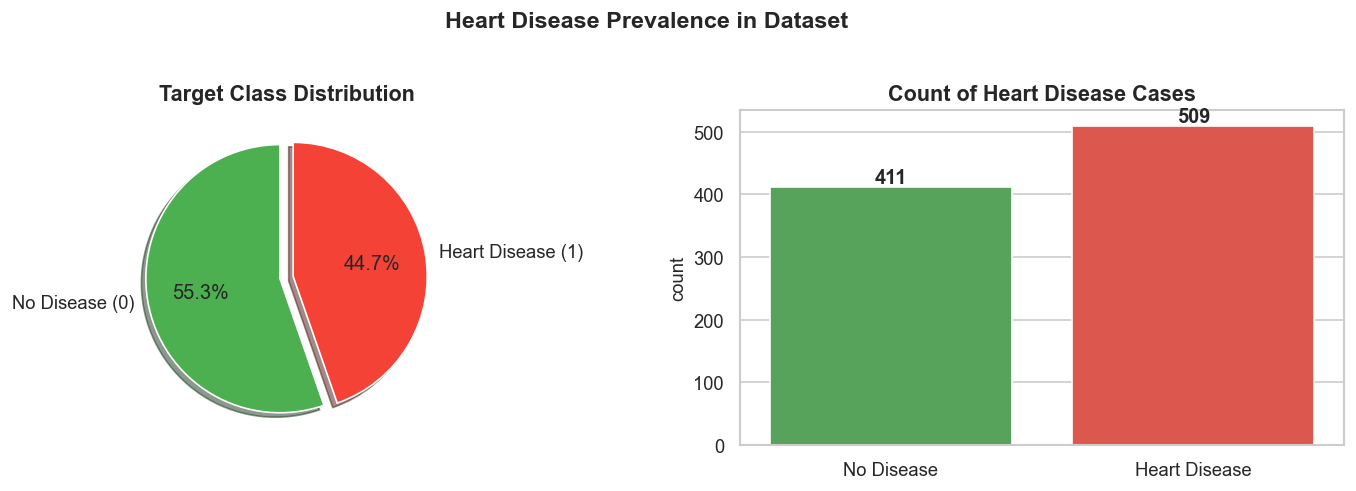

In [83]:
#  3.3 Target Distribution 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['target'].value_counts()
labels = ['No Disease (0)', 'Heart Disease (1)']
colors = ['#4CAF50', '#F44336']

axes[0].pie(target_counts, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, explode=(0.05, 0.05), shadow=True)
axes[0].set_title('Target Class Distribution', fontweight='bold')

sns.countplot(x='target', data=df, palette=['#4CAF50', '#F44336'], ax=axes[1])
axes[1].set_title('Count of Heart Disease Cases', fontweight='bold')
axes[1].set_xticklabels(['No Disease', 'Heart Disease'])
axes[1].set_xlabel('')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.suptitle('Heart Disease Prevalence in Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight')
plt.show()


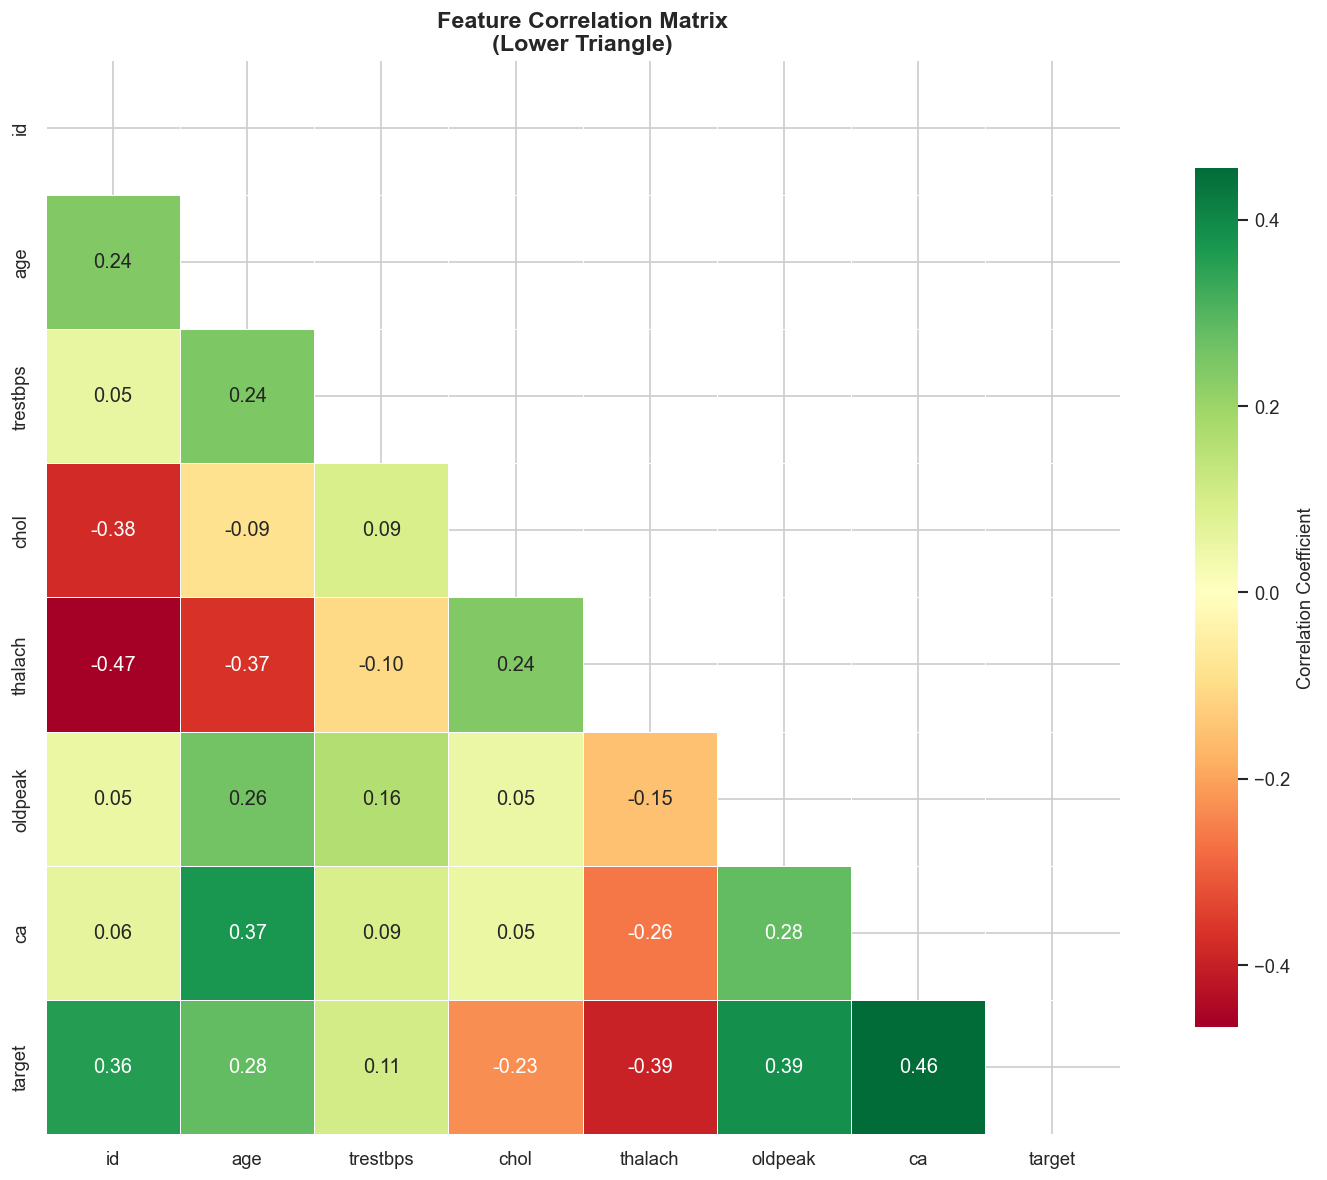


 Top features correlated with 'target':
ca          0.46
thalach    -0.39
oldpeak     0.39
id          0.36
age         0.28
chol       -0.23
trestbps    0.11
Name: target, dtype: float64


In [84]:
# 3.4 Correlation Heatmap 
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(13, 10))
corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)
plt.title('Feature Correlation Matrix\n(Lower Triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Top correlations with target
print("\n Top features correlated with 'target':")
print(corr_matrix['target'].sort_values(key=abs, ascending=False).drop('target'))

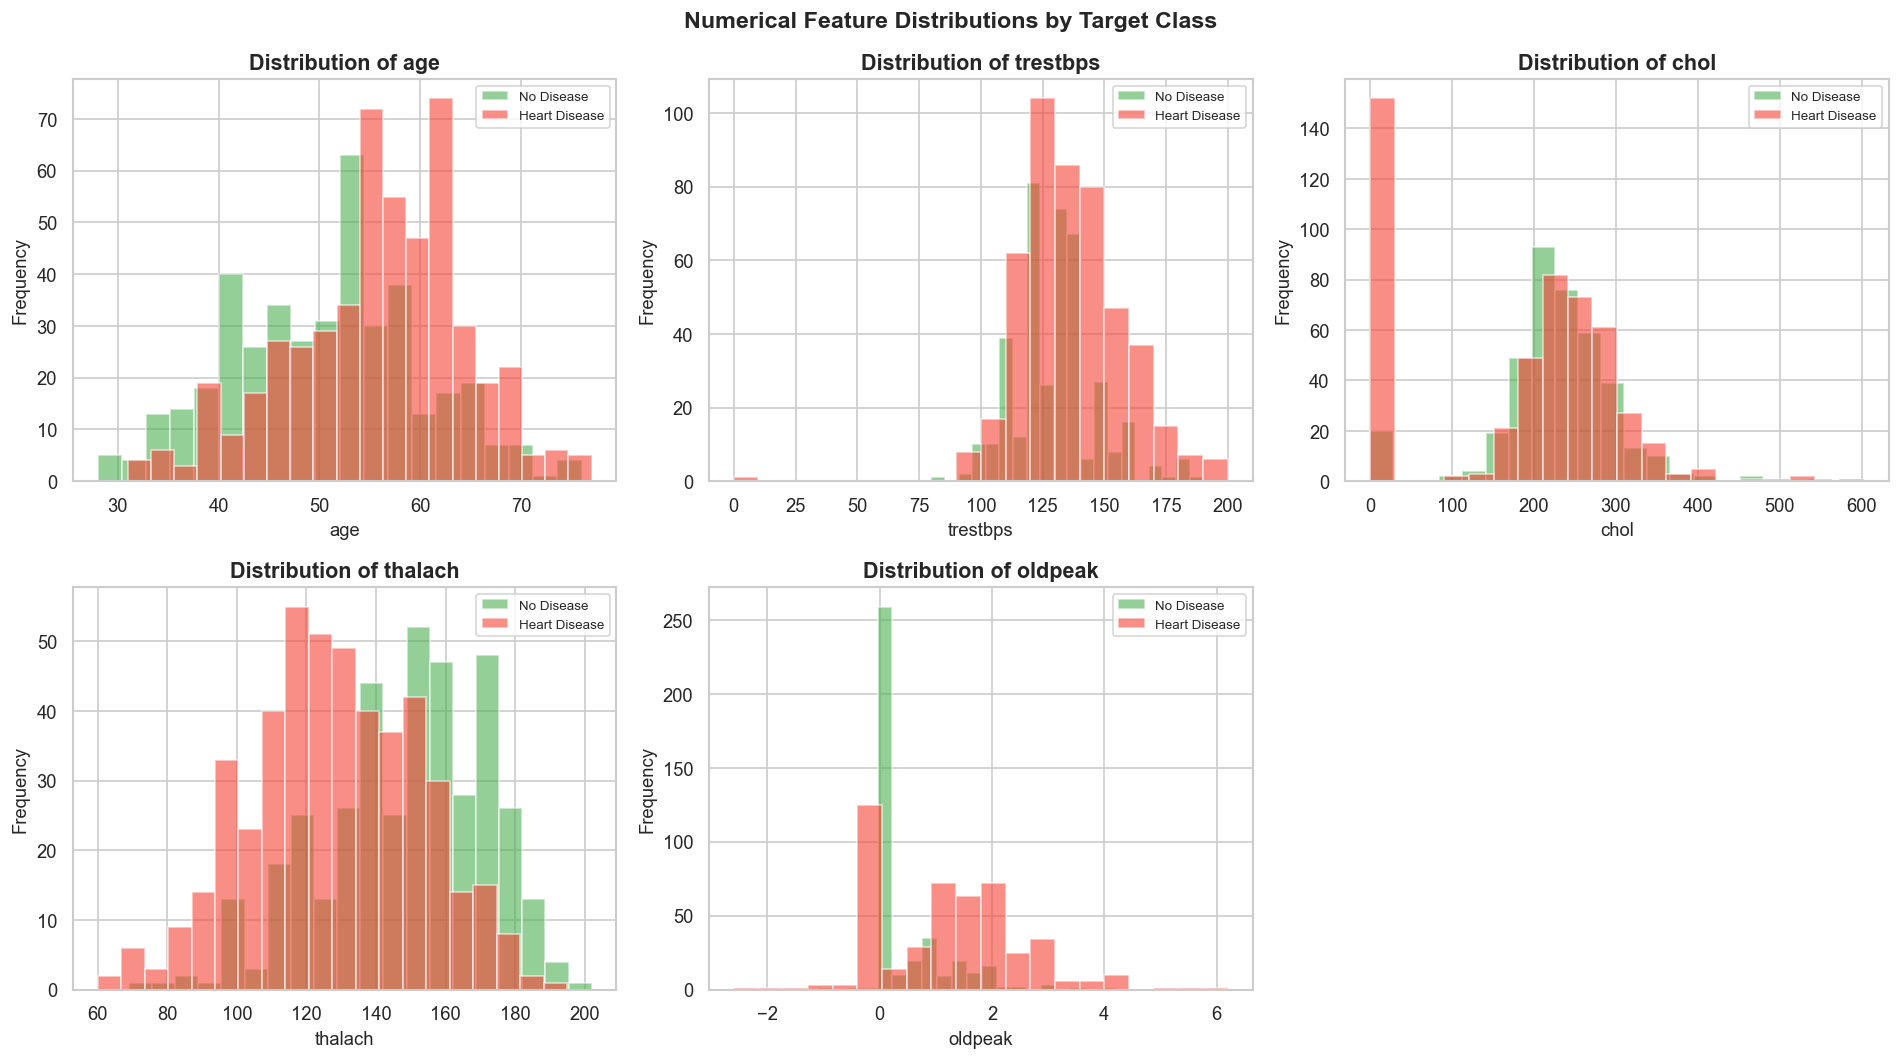

In [85]:
#  3.5 Feature Distributions (Histograms)
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    ax = axes[i]
    for target_val, color, label in [(0, '#4CAF50', 'No Disease'), (1, '#F44336', 'Heart Disease')]:
        ax.hist(df[df['target'] == target_val][col], bins=20, alpha=0.6,
                color=color, label=label, edgecolor='white')
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Numerical Feature Distributions by Target Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_histograms.png', bbox_inches='tight')
plt.show()

In [86]:
# ── 3.5 Feature Distributions (Histograms) — Plotly ─────────────────────────
import plotly.graph_objects as go
from plotly.subplots import make_subplots

numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[f'Distribution of {col}' for col in numerical_features],
    vertical_spacing=0.12,
    horizontal_spacing=0.08
)

colors = {0: '#4CAF50', 1: '#F44336'}
labels = {0: 'No Disease',  1: 'Heart Disease'}
positions = [(1,1), (1,2), (1,3), (2,1), (2,2)]

for i, (col, (row, col_pos)) in enumerate(zip(numerical_features, positions)):
    for target_val in [0, 1]:
        subset = df[df['target'] == target_val][col].dropna()
        fig.add_trace(
            go.Histogram(
                x=subset,
                nbinsx=20,
                name=labels[target_val],
                marker_color=colors[target_val],
                opacity=0.6,
                legendgroup=str(target_val),
                showlegend=(i == 0),
                hovertemplate=f"<b>{labels[target_val]}</b><br>{col}: %{{x}}<br>Count: %{{y}}<extra></extra>"
            ),
            row=row, col=col_pos
        )

fig.update_layout(
    title=dict(text='Numerical Feature Distributions by Target Class', font=dict(size=16), x=0.5),
    barmode='overlay',
    height=620,
    width=1100,
    legend=dict(title='Diagnosis', x=0.88, y=0.25),
    plot_bgcolor='white',
    paper_bgcolor='white',
)

fig.update_xaxes(showgrid=True, gridcolor='#f0f0f0')
fig.update_yaxes(showgrid=True, gridcolor='#f0f0f0', title_text='Frequency')
fig.update_xaxes(visible=False, row=2, col=3)
fig.update_yaxes(visible=False, row=2, col=3)

# ✅ Save and display — works in VS Code without nbformat
fig.write_html('feature_histograms.html')
print("✅ Chart saved as 'feature_histograms.html'")
print("📂 Open this file in your browser for the interactive chart")

# Inline d

✅ Chart saved as 'feature_histograms.html'
📂 Open this file in your browser for the interactive chart


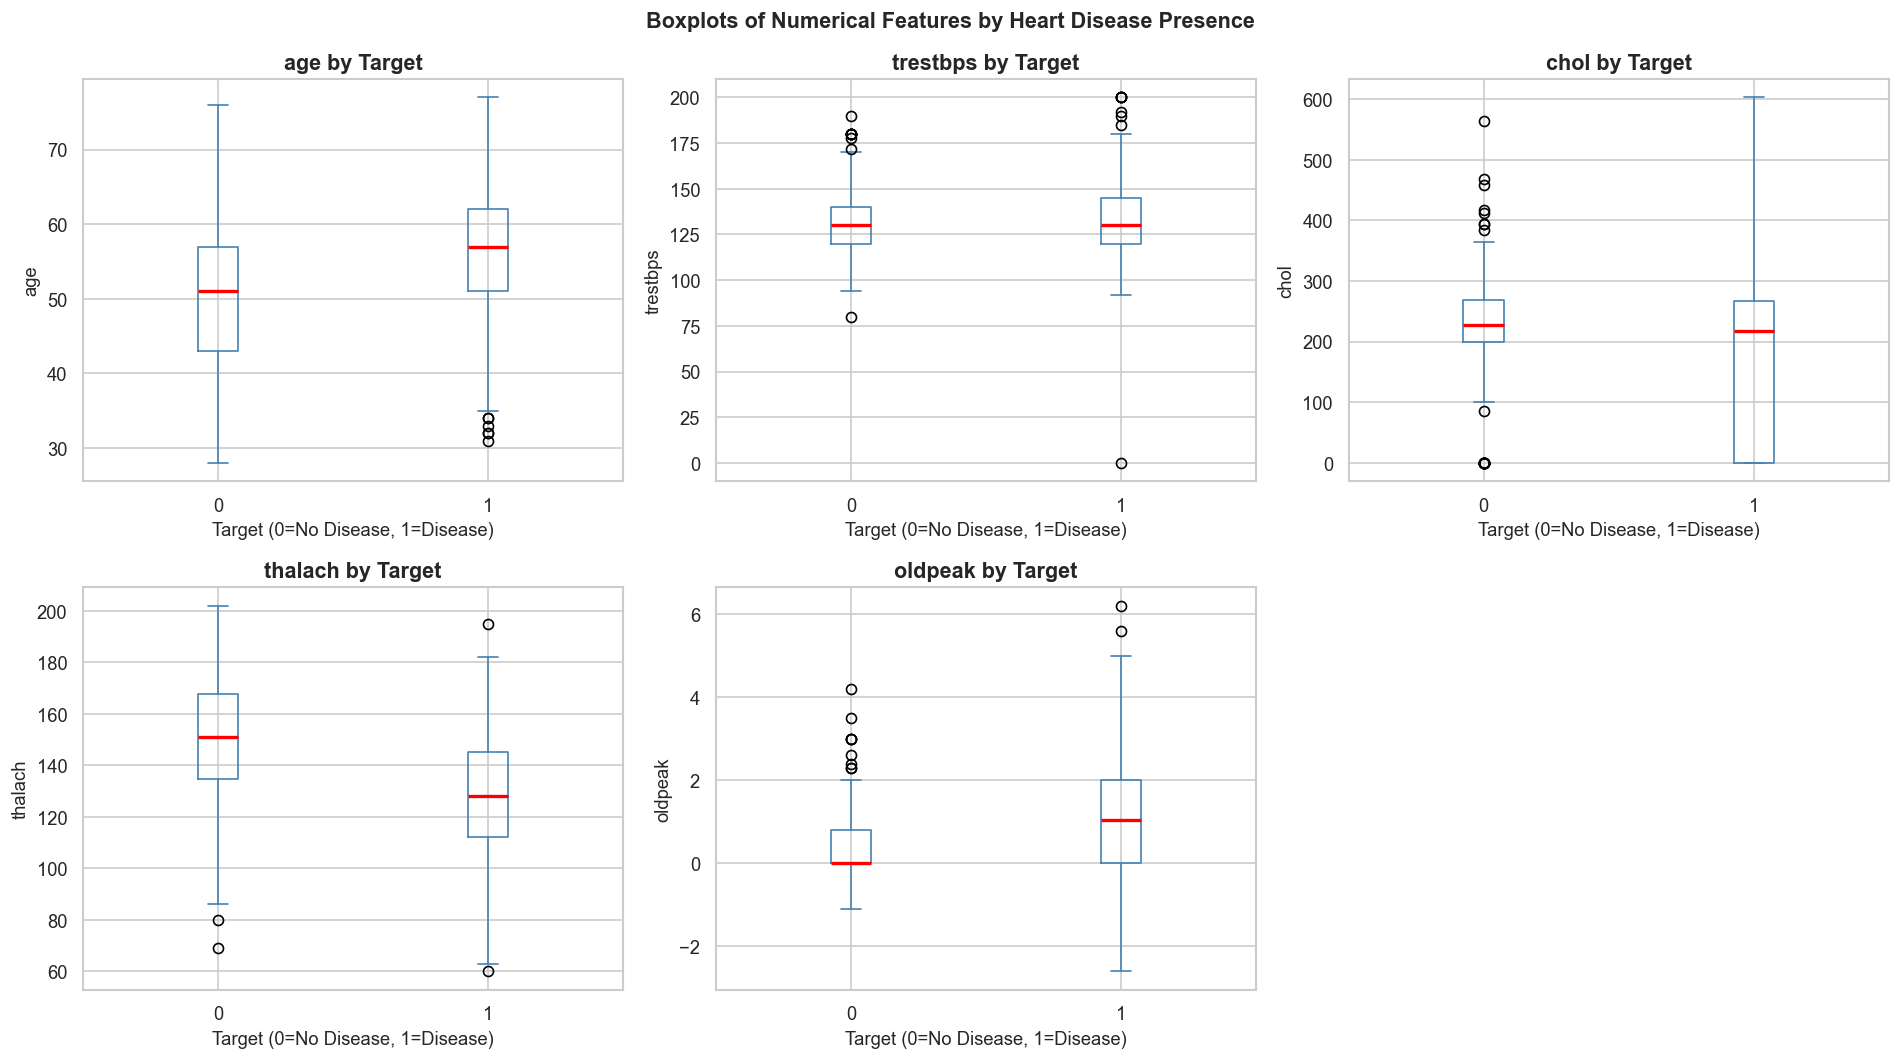

In [87]:
# 3.6 Boxplots by Target Class 
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    ax = axes[i]
    df.boxplot(column=col, by='target', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='steelblue'),
               capprops=dict(color='steelblue'))
    ax.set_title(f'{col} by Target', fontweight='bold')
    ax.set_xlabel('Target (0=No Disease, 1=Disease)')
    ax.set_ylabel(col)

axes[-1].set_visible(False)
plt.suptitle('Boxplots of Numerical Features by Heart Disease Presence', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_boxplots.png', bbox_inches='tight')
plt.show()

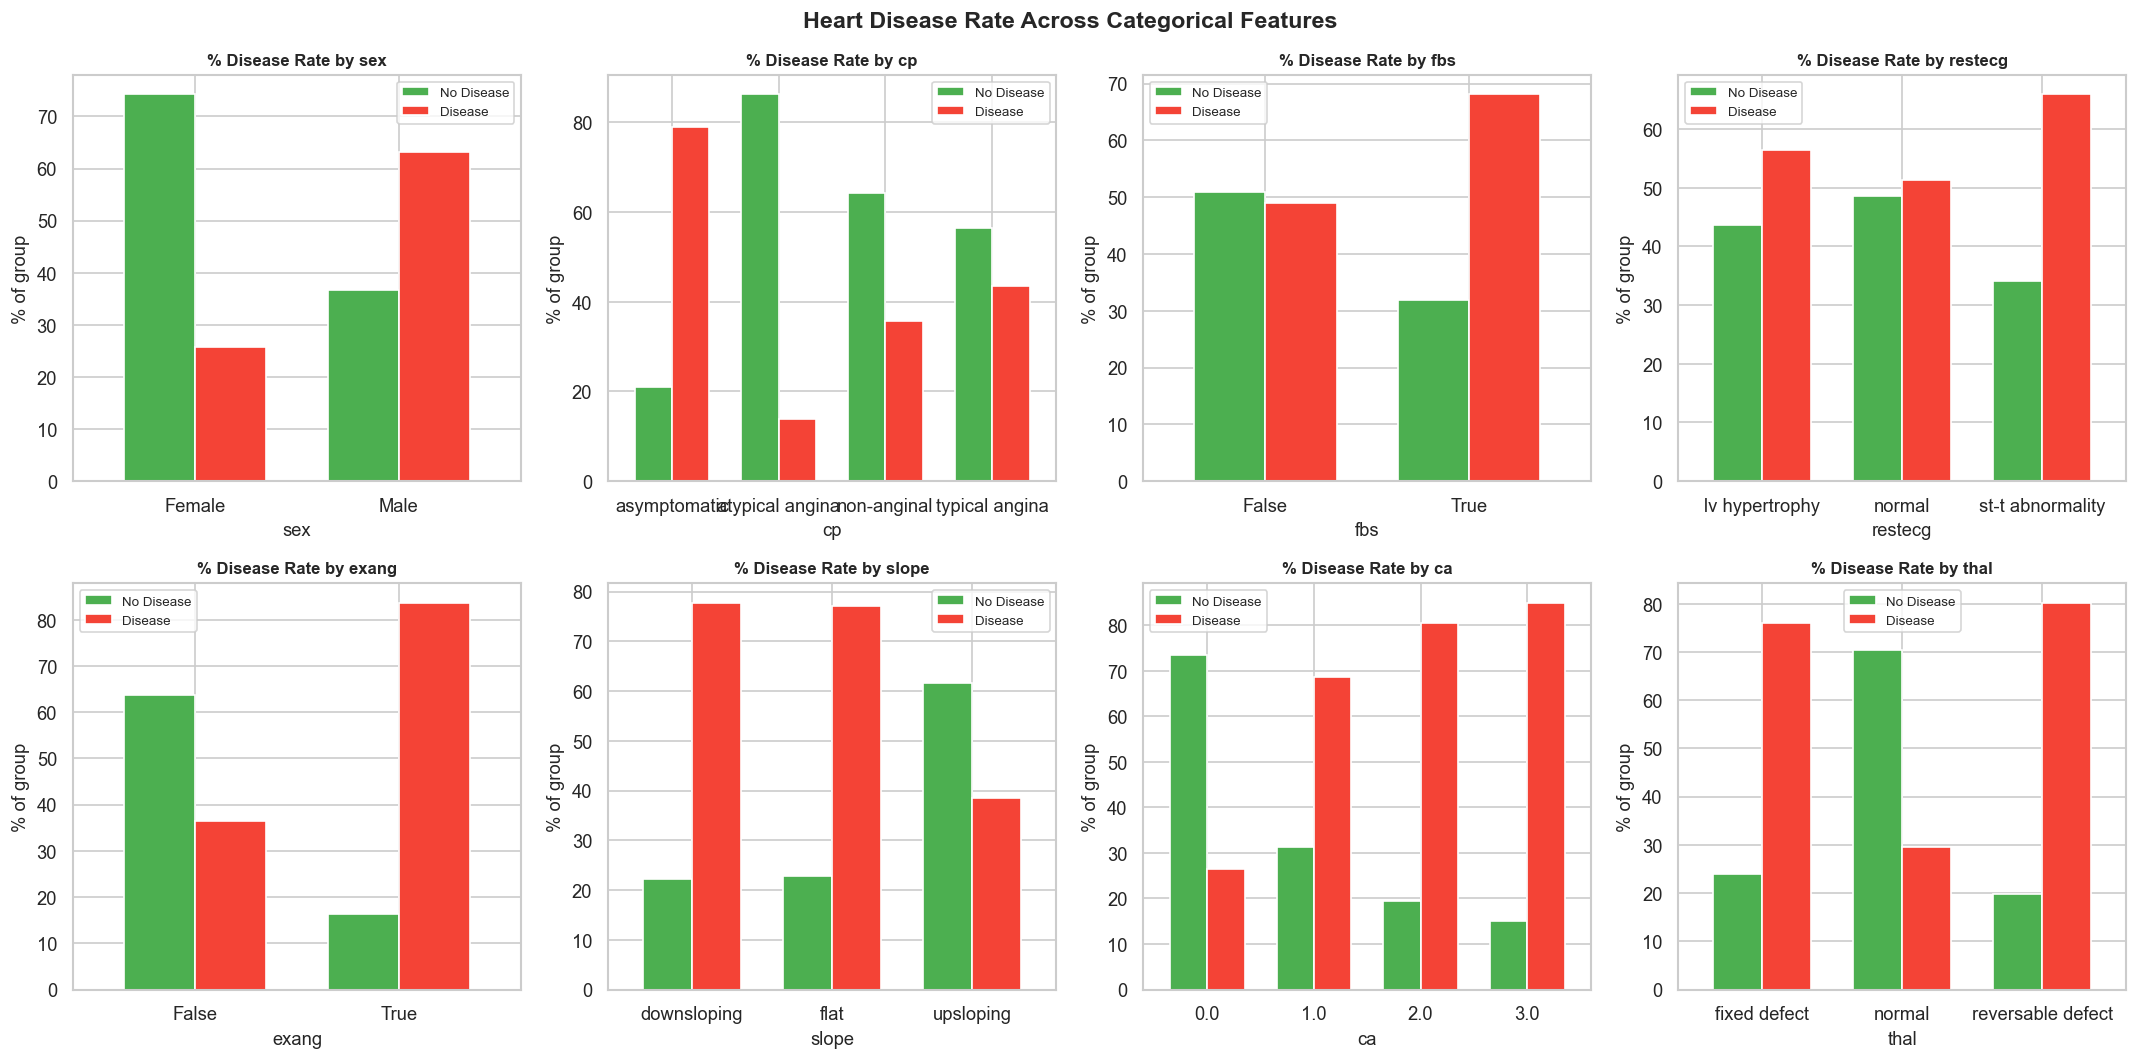

In [88]:
# 3.7 Categorical Feature Analysis 
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#4CAF50', '#F44336'],
            edgecolor='white', width=0.7)
    axes[i].set_title(f'% Disease Rate by {col}', fontweight='bold', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('% of group')
    axes[i].legend(['No Disease', 'Disease'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Heart Disease Rate Across Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_analysis.png', bbox_inches='tight')
plt.show()

##  Section 4: Data Preprocessing

Clean and transform the data to make it suitable for machine learning models.

In [89]:
def preprocess_data(df: pd.DataFrame) -> tuple:
    df_clean = df.copy()

    #  Step 1: Handle Missing Values 
    print(" Missing values before handling:")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

    # Numerical: fill with median (robust to outliers)
    num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c != 'target']
    for col in num_cols:
        if df_clean[col].isnull().sum() > 0:
            median_val = df_clean[col].median()
            df_clean[col].fillna(median_val, inplace=True)
            print(f"   Filled '{col}' with median ({median_val:.2f})")

    # Categorical: fill with mode
    cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
    for col in cat_cols:
        if df_clean[col].isnull().sum() > 0:
            mode_val = df_clean[col].mode()[0]
            df_clean[col].fillna(mode_val, inplace=True)
            print(f"   Filled '{col}' with mode ({mode_val})")

    print(f"\nMissing values after handling: {df_clean.isnull().sum().sum()}")

    # Step 2: Encode Categorical Features
    # In the UCI dataset, all features are already numerical (0/1/integers)
    # We treat multi-class integer columns (cp, restecg, slope, thal) as categoricals
    # using one-hot encoding to avoid ordinal assumptions
    ordinal_cats = ['cp', 'restecg', 'slope', 'thal']
    existing_ordinal = [c for c in ordinal_cats if c in df_clean.columns]
    
    if existing_ordinal:
        df_encoded = pd.get_dummies(df_clean, columns=existing_ordinal, drop_first=False)
        # Convert bool columns to int
        bool_cols = df_encoded.select_dtypes(include='bool').columns
        df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
        print(f"\n One-hot encoded: {existing_ordinal}")
    else:
        df_encoded = df_clean.copy()

    #  Step 3: Separate Features & Target 
    X = df_encoded.drop('target', axis=1)
    y = df_encoded['target']
    feature_names = X.columns.tolist()

    print(f"\n Feature matrix shape: {X.shape}")
    print(f" Target distribution:\n{y.value_counts()}")

    # Step 4: Train/Test Split 
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"\n Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

    #Step 5: Scale Numerical Features
    continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
    continuous_cols = [c for c in continuous_cols if c in X_train.columns]

    scaler = StandardScaler()
    X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
    X_test[continuous_cols]  = scaler.transform(X_test[continuous_cols])
    print(f" Scaled features: {continuous_cols}")

    return X_train, X_test, y_train, y_test, feature_names, scaler, continuous_cols


X_train, X_test, y_train, y_test, feature_names, scaler, continuous_cols = preprocess_data(df)
print("\n Preprocessing complete!")

 Missing values before handling:
trestbps     59
chol         30
fbs          90
restecg       2
thalach      55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64
   Filled 'trestbps' with median (130.00)
   Filled 'chol' with median (223.00)
   Filled 'thalach' with median (140.00)
   Filled 'oldpeak' with median (0.50)
   Filled 'ca' with median (0.00)
   Filled 'fbs' with mode (False)
   Filled 'restecg' with mode (normal)
   Filled 'exang' with mode (False)
   Filled 'slope' with mode (flat)
   Filled 'thal' with mode (normal)

Missing values after handling: 0

 One-hot encoded: ['cp', 'restecg', 'slope', 'thal']

 Feature matrix shape: (920, 24)
 Target distribution:
target
1    509
0    411
Name: count, dtype: int64

 Train size: 736 | Test size: 184
 Scaled features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

 Preprocessing complete!


##  Section 6: Model Training

We train **Random Forest** and **XGBoost** classifiers with hyperparameter tuning via Grid Search and Stratified Cross-Validation.

In [90]:
#  6.1 Define Models & Hyperparameter Grids 

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(" Hyperparameter grids defined")

 Hyperparameter grids defined


In [91]:
# ── Encode remaining string columns before modeling ──────────────────────────
from sklearn.preprocessing import LabelEncoder

# Check for any remaining object/string columns
string_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(f"String columns found: {string_cols}")

le = LabelEncoder()
for col in string_cols:
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))
    print(f" Encoded: {col}")

print("\n All columns are now numeric. Ready for training.")
print(f"X_train dtypes:\n{X_train.dtypes}")

String columns found: ['sex', 'dataset']
 Encoded: sex
 Encoded: dataset

 All columns are now numeric. Ready for training.
X_train dtypes:
id                            int64
age                         float64
sex                           int64
dataset                       int64
trestbps                    float64
chol                        float64
fbs                           int64
thalach                     float64
exang                         int64
oldpeak                     float64
ca                          float64
cp_asymptomatic               int64
cp_atypical angina            int64
cp_non-anginal                int64
cp_typical angina             int64
restecg_lv hypertrophy        int64
restecg_normal                int64
restecg_st-t abnormality      int64
slope_downsloping             int64
slope_flat                    int64
slope_upsloping               int64
thal_fixed defect             int64
thal_normal                   int64
thal_reversable defect        in

In [92]:
# 6.2 Train Random Forest with Grid Search 
print(" Training Random Forest with Grid Search CV...")
print("   This may take a few minutes...")

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(
    rf_base, rf_param_grid, cv=cv_strategy,
    scoring='roc_auc', n_jobs=-1, verbose=0
)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print(f"\n Best RF Parameters: {rf_grid.best_params_}")
print(f"   Best CV ROC-AUC  : {rf_grid.best_score_:.4f}")

 Training Random Forest with Grid Search CV...
   This may take a few minutes...

 Best RF Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
   Best CV ROC-AUC  : 0.9334


In [93]:
# 6.3 Train XGBoost with Grid Search 
print("⚡ Training XGBoost with Grid Search CV...")
print("   This may take a few minutes...")

xgb_base = XGBClassifier(
    random_state=42, use_label_encoder=False,
    eval_metric='logloss', n_jobs=-1, verbosity=0
)
xgb_grid = GridSearchCV(
    xgb_base, xgb_param_grid, cv=cv_strategy,
    scoring='roc_auc', n_jobs=-1, verbose=0
)
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
print(f"\n Best XGB Parameters: {xgb_grid.best_params_}")
print(f"   Best CV ROC-AUC   : {xgb_grid.best_score_:.4f}")

⚡ Training XGBoost with Grid Search CV...
   This may take a few minutes...

 Best XGB Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
   Best CV ROC-AUC   : 0.9341


In [94]:
# 6.4 Cross-Validation Comparison 
print(" Cross-Validation Performance Comparison")
print("=" * 50)

for name, model in [('Random Forest', best_rf), ('XGBoost', best_xgb)]:
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv_strategy, scoring='roc_auc')
    print(f"{name:15s} | CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

 Cross-Validation Performance Comparison
Random Forest   | CV ROC-AUC: 0.9334 ± 0.0173
XGBoost         | CV ROC-AUC: 0.9345 ± 0.0085


##  Section 7: Model Evaluation

Thorough evaluation using multiple metrics to understand each model's performance from different angles.

In [95]:
def evaluate_model(model, X_test: pd.DataFrame, y_test: pd.Series, model_name: str) -> dict:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        'model': model_name,
        'accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'precision': round(precision_score(y_test, y_pred), 4),
        'recall':    round(recall_score(y_test, y_pred), 4),
        'f1':        round(f1_score(y_test, y_pred), 4),
        'roc_auc':   round(roc_auc_score(y_test, y_prob), 4),
        'y_pred':    y_pred,
        'y_prob':    y_prob
    }

    print(f"\n{'='*55}")
    print(f"  {model_name} — Test Set Evaluation")
    print(f"{'='*55}")
    print(f"  Accuracy  : {metrics['accuracy']:.4f}")
    print(f"  Precision : {metrics['precision']:.4f}")
    print(f"  Recall    : {metrics['recall']:.4f}")
    print(f"  F1-Score  : {metrics['f1']:.4f}")
    print(f"  ROC-AUC   : {metrics['roc_auc']:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Disease', 'Heart Disease']))

    return metrics


rf_metrics  = evaluate_model(best_rf,  X_test, y_test, 'Random Forest')
xgb_metrics = evaluate_model(best_xgb, X_test, y_test, 'XGBoost')


  Random Forest — Test Set Evaluation
  Accuracy  : 0.8804
  Precision : 0.8509
  Recall    : 0.9510
  F1-Score  : 0.8981
  ROC-AUC   : 0.9582

  Classification Report:
               precision    recall  f1-score   support

   No Disease       0.93      0.79      0.86        82
Heart Disease       0.85      0.95      0.90       102

     accuracy                           0.88       184
    macro avg       0.89      0.87      0.88       184
 weighted avg       0.89      0.88      0.88       184


  XGBoost — Test Set Evaluation
  Accuracy  : 0.8967
  Precision : 0.8739
  Recall    : 0.9510
  F1-Score  : 0.9108
  ROC-AUC   : 0.9603

  Classification Report:
               precision    recall  f1-score   support

   No Disease       0.93      0.83      0.88        82
Heart Disease       0.87      0.95      0.91       102

     accuracy                           0.90       184
    macro avg       0.90      0.89      0.89       184
 weighted avg       0.90      0.90      0.90       184



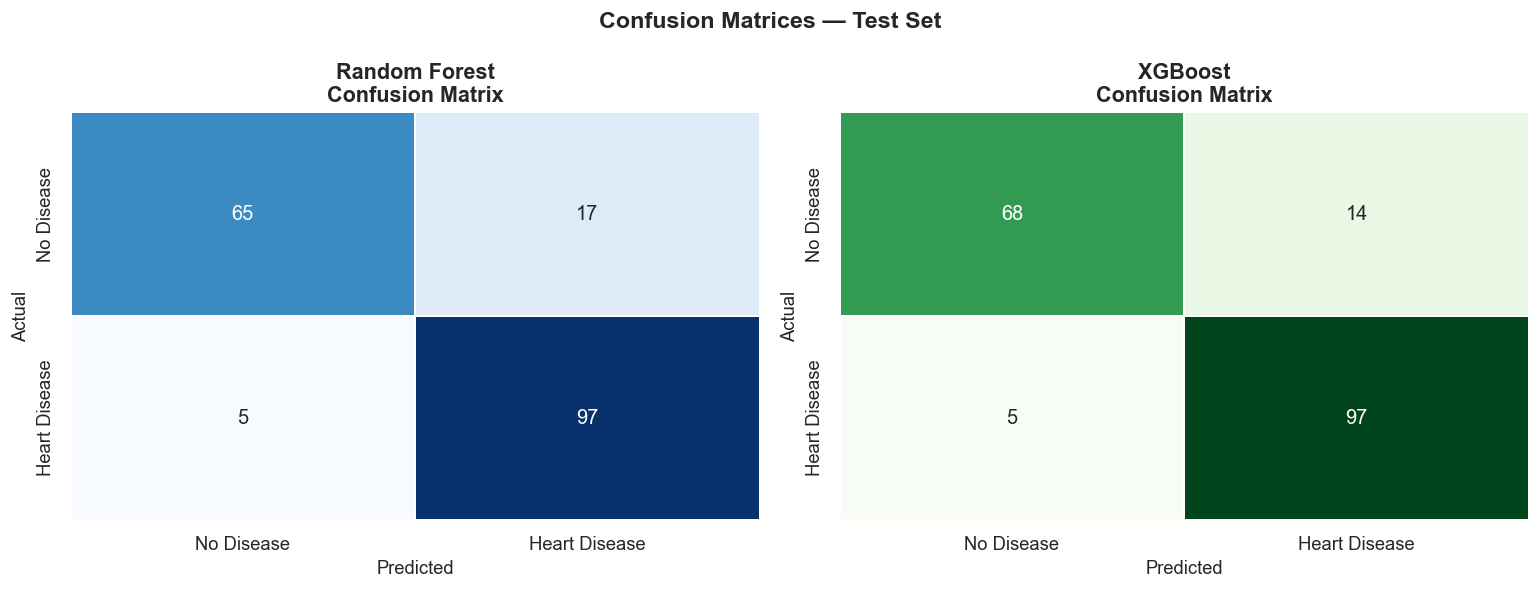

In [96]:
# 7.1 Confusion Matrices 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metrics, cmap in zip(axes, [rf_metrics, xgb_metrics], ['Blues', 'Greens']):
    cm = confusion_matrix(y_test, metrics['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['No Disease', 'Heart Disease'],
                yticklabels=['No Disease', 'Heart Disease'],
                linewidths=1, linecolor='white', cbar=False)
    ax.set_title(f"{metrics['model']}\nConfusion Matrix", fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

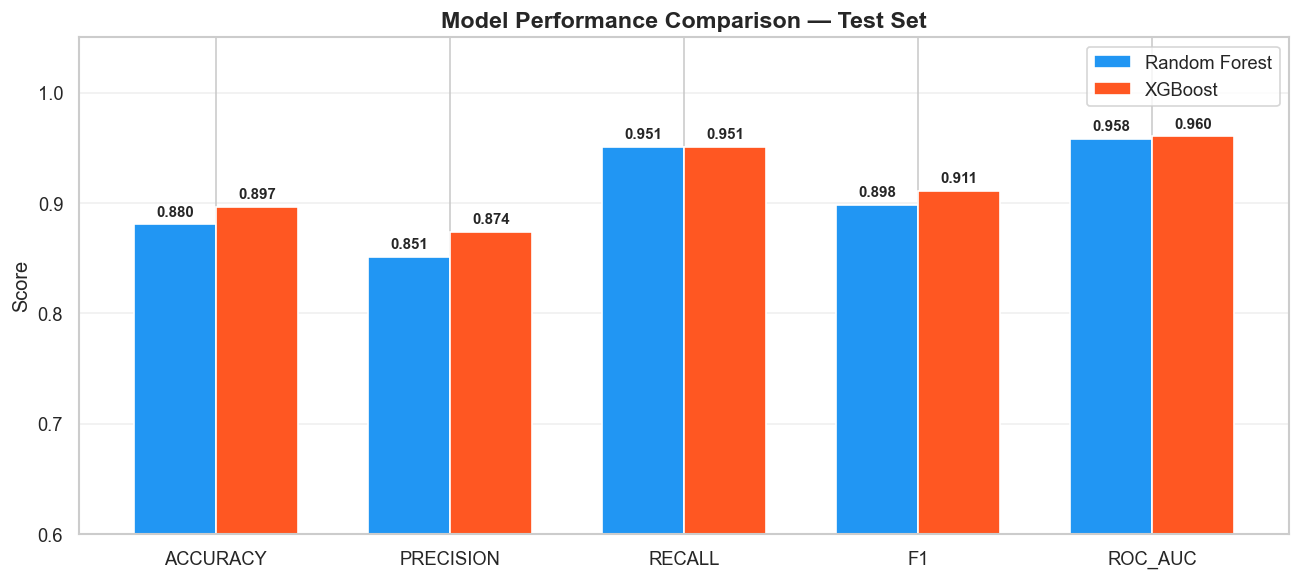

In [97]:
#  7.3 Metrics Comparison Dashboard 
metric_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
rf_vals  = [rf_metrics[m] for m in metric_names]
xgb_vals = [xgb_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, rf_vals,  width, label='Random Forest', color='#2196F3', edgecolor='white')
bars2 = ax.bar(x + width/2, xgb_vals, width, label='XGBoost',       color='#FF5722', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metric_names], fontsize=11)
ax.set_ylim([0.6, 1.05])
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — Test Set', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_comparison.png', bbox_inches='tight')
plt.show()

##  Section 8: Predictions & Clinical Insights

Generate predictions on test data and extract actionable insights for preventive care.

In [98]:
#  8.1 Select Best Model 
best_model_name = 'Random Forest' if rf_metrics['roc_auc'] >= xgb_metrics['roc_auc'] else 'XGBoost'
best_model = best_rf if best_model_name == 'Random Forest' else best_xgb
print(f" Best Model: {best_model_name} (ROC-AUC = {max(rf_metrics['roc_auc'], xgb_metrics['roc_auc']):.4f})")

 Best Model: XGBoost (ROC-AUC = 0.9603)


In [99]:
#  8.2 Predictions on Test Set 
test_predictions = X_test.copy()
test_predictions['actual_target']  = y_test.values
test_predictions['predicted_label']= best_model.predict(X_test)
test_predictions['risk_probability']= best_model.predict_proba(X_test)[:, 1]

# Risk category
def risk_category(prob):
    if prob < 0.3:   return 'Low Risk'
    elif prob < 0.6: return 'Moderate Risk'
    else:            return 'High Risk'

test_predictions['risk_category'] = test_predictions['risk_probability'].apply(risk_category)

print("Sample Predictions (first 10 rows):")
print(test_predictions[['actual_target','predicted_label','risk_probability','risk_category']].head(10).to_string())

# Save predictions
test_predictions.to_csv('test_predictions.csv', index=False)
print("\n Predictions saved to 'test_predictions.csv'")

Sample Predictions (first 10 rows):
     actual_target  predicted_label  risk_probability  risk_category
514              1                1              0.93      High Risk
825              1                1              0.95      High Risk
854              1                1              0.86      High Risk
804              1                1              0.95      High Risk
887              0                1              0.61      High Risk
483              0                0              0.15       Low Risk
273              0                0              0.31  Moderate Risk
540              1                1              0.98      High Risk
402              0                0              0.03       Low Risk
601              1                1              0.92      High Risk

 Predictions saved to 'test_predictions.csv'


 Top 10 Risk Factors:
 rank                feature  importance  importance_pct
    1                dataset        0.13           13.17
    2                     ca        0.11           10.93
    3        cp_asymptomatic        0.11           10.91
    4                  exang        0.10           10.26
    5 thal_reversable defect        0.09            9.21
    6            thal_normal        0.09            8.77
    7                     id        0.09            8.57
    8                    sex        0.04            3.56
    9                oldpeak        0.03            3.48
   10        slope_upsloping        0.03            2.69


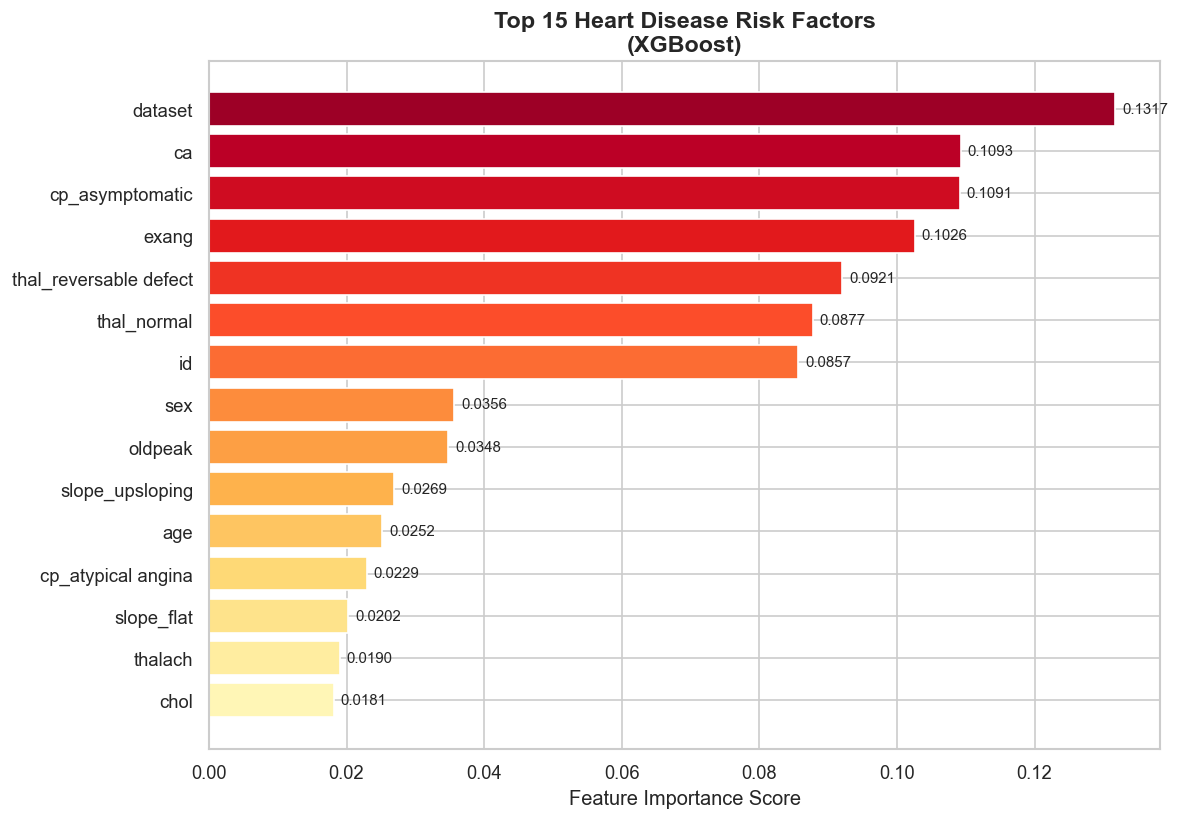

In [100]:
# 8.3 Top Risk Factors & Feature Importance 
importances = best_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

feat_imp_df['rank'] = range(1, len(feat_imp_df) + 1)
feat_imp_df['importance_pct'] = (feat_imp_df['importance'] / feat_imp_df['importance'].sum() * 100).round(2)

print(" Top 10 Risk Factors:")
print(feat_imp_df.head(10)[['rank', 'feature', 'importance', 'importance_pct']].to_string(index=False))

# Save feature importance
feat_imp_df.to_csv('feature_importance.csv', index=False)

# Plot top 15 features
top15 = feat_imp_df.head(15).sort_values('importance')
colors_grad = sns.color_palette('YlOrRd', len(top15))

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15['feature'], top15['importance'], color=colors_grad)
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title(f'Top 15 Heart Disease Risk Factors\n({best_model_name})', fontsize=14, fontweight='bold')

for i, (imp, feat) in enumerate(zip(top15['importance'], top15['feature'])):
    ax.text(imp + 0.001, i, f'{imp:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_risk_factors.png', bbox_inches='tight')
plt.show()

In [101]:
#  8.4 Actionable Clinical Insights 
insights = {
    'thalach':  '💓 LOW MAX HEART RATE: Patients with thalach < 140 bpm show significantly higher risk. '
                'Recommendation: Regular aerobic exercise programs to improve cardiac reserve.',
    'cp':       '⚠️  CHEST PAIN TYPE: Asymptomatic (type 0) patients paradoxically show higher risk — '
                'silent ischemia is dangerous. Recommendation: Routine ECG screening for all adults 45+.',
    'ca':       '🩺 VESSEL BLOCKAGE (ca): More blocked major vessels = dramatically higher risk. '
                'Recommendation: Lipid-lowering therapy and angiography referral for ca ≥ 1.',
    'oldpeak':  '📉 ST DEPRESSION: Higher oldpeak values indicate cardiac stress under exercise. '
                'Recommendation: Exercise stress testing and echocardiography evaluation.',
    'thal':     '🧬 THALASSEMIA TYPE: Fixed defect thal type correlates with higher risk. '
                'Recommendation: Genetic counseling and enhanced monitoring for affected patients.',
    'exang':    '🏃 EXERCISE ANGINA: Exercise-induced angina is a strong predictor. '
                'Recommendation: Supervised cardiac rehab and anti-anginal medications.',
    'age':      '📅 AGE: Risk increases significantly after 55. '
                'Recommendation: Annual cardiovascular risk assessments for all patients 55+.',
    'chol':     '🥩 CHOLESTEROL: Elevated cholesterol (>240) compounds risk. '
                'Recommendation: Dietary intervention + statins where appropriate.',
    'sex':      '♂️  MALE SEX: Males in this dataset show higher baseline risk. '
                'Recommendation: Gender-specific screening timelines (earlier for men).',
    'trestbps': '🔴 BLOOD PRESSURE: Resting hypertension (>140) is a modifiable risk factor. '
                'Recommendation: Antihypertensive therapy + low-sodium diet.',
}

top_features = feat_imp_df['feature'].head(10).tolist()
print("\n🏥 ACTIONABLE PREVENTIVE CARE INSIGHTS")
print("=" * 70)
for feat in top_features:
    # Match partial feature names (for OHE columns)
    for key in insights:
        if key in feat:
            print(f"\n{insights[key]}")
            break


🏥 ACTIONABLE PREVENTIVE CARE INSIGHTS

🩺 VESSEL BLOCKAGE (ca): More blocked major vessels = dramatically higher risk. Recommendation: Lipid-lowering therapy and angiography referral for ca ≥ 1.

⚠️  CHEST PAIN TYPE: Asymptomatic (type 0) patients paradoxically show higher risk — silent ischemia is dangerous. Recommendation: Routine ECG screening for all adults 45+.

🏃 EXERCISE ANGINA: Exercise-induced angina is a strong predictor. Recommendation: Supervised cardiac rehab and anti-anginal medications.

🧬 THALASSEMIA TYPE: Fixed defect thal type correlates with higher risk. Recommendation: Genetic counseling and enhanced monitoring for affected patients.

🧬 THALASSEMIA TYPE: Fixed defect thal type correlates with higher risk. Recommendation: Genetic counseling and enhanced monitoring for affected patients.

♂️  MALE SEX: Males in this dataset show higher baseline risk. Recommendation: Gender-specific screening timelines (earlier for men).

📉 ST DEPRESSION: Higher oldpeak values indicate

In [102]:
#  8.5 Save Models for Dashboard 
joblib.dump(best_model, 'heart_disease_model.pkl')
joblib.dump(scaler,     'heart_disease_scaler.pkl')
joblib.dump(feat_imp_df, 'feature_importance.pkl')

# Save metadata for Streamlit
metadata = {
    'best_model': best_model_name,
    'features': list(X_train.columns),
    'continuous_cols': continuous_cols,
    'metrics': {
        'accuracy':  float(max(rf_metrics['accuracy'], xgb_metrics['accuracy'])),
        'roc_auc':   float(max(rf_metrics['roc_auc'], xgb_metrics['roc_auc'])),
        'f1':        float(max(rf_metrics['f1'], xgb_metrics['f1'])),
    }
}
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(" Model, scaler, and metadata saved to disk for Streamlit dashboard")

 Model, scaler, and metadata saved to disk for Streamlit dashboard


##  Section 10: Summary & Next Steps

### 🏆 What We Built

| Component | Details |
|-----------|----------|
| **Dataset** | Heart Disease UCI (303 patients, 13 clinical features) |
| **EDA** | Target distribution, correlations, histograms, boxplots, categorical analysis |
| **Preprocessing** | Median/mode imputation, one-hot encoding, StandardScaler |
| **Feature Engineering** | age_group, high_chol, hypertension, low_thalach, risk_score |
| **Models** | Random Forest + XGBoost with GridSearchCV (5-fold stratified CV) |
| **Evaluation** | Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix, ROC curves |
| **Insights** | Top risk factors + actionable preventive care recommendations |
| **Dashboard** | Full Streamlit app with prediction, feature importance, and CSV download |

### 🚀 Suggested Next Steps
1. **More Data**: Augment with the full Cleveland + Hungary UCI combined dataset
2. **Advanced Models**: Try LightGBM, CatBoost, or an ensemble/stacking approach
3. **SHAP Explainability**: Use SHAP values for per-patient, model-agnostic explanations
4. **Class Imbalance**: Apply SMOTE or class weighting if you work with more imbalanced data
5. **Clinical Validation**: Partner with clinicians to validate predictions against real outcomes
6. **Deploy**: Package the Streamlit app with Docker and deploy to AWS/GCP/Azure
7. **Monitoring**: Add MLflow or Weights & Biases for experiment tracking and drift detection

---
⚠️ **Disclaimer**: This project is for educational purposes only and should not be used as a substitute for professional medical advice, diagnosis, or treatment.

In [104]:
#  Final Summary 
print("╔══════════════════════════════════════════════════════════════╗")
print("║     🫀 HEART DISEASE PREDICTIVE ANALYTICS — COMPLETE!       ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  Best Model    : {metadata['best_model']:<42}║")
print(f"║  Test Accuracy : {metadata['metrics']['accuracy']:.4f}{'':<37}║")
print(f"║  Test ROC-AUC  : {metadata['metrics']['roc_auc']:.4f}{'':<37}║")
print(f"║  Test F1-Score : {metadata['metrics']['f1']:.4f}{'':<37}║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  Files Created:                                              ║")
print("║   heart_disease_model.pkl  — Trained ML model             ║")
print("║   feature_importance.pkl   — Feature rankings             ║")
print("║   heart_disease_scaler.pkl — Fitted StandardScaler        ║")
print("║   model_metadata.json      — Model config & metrics       ║")
print("║   test_predictions.csv     — Test set predictions         ║")
print("║    app.py                   — Streamlit dashboard          ║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  ▶ Launch dashboard: streamlit run app.py                  ║")
print("╚══════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════╗
║     🫀 HEART DISEASE PREDICTIVE ANALYTICS — COMPLETE!       ║
╠══════════════════════════════════════════════════════════════╣
║  Best Model    : XGBoost                                   ║
║  Test Accuracy : 0.8967                                     ║
║  Test ROC-AUC  : 0.9603                                     ║
║  Test F1-Score : 0.9108                                     ║
╠══════════════════════════════════════════════════════════════╣
║  Files Created:                                              ║
║   heart_disease_model.pkl  — Trained ML model             ║
║   feature_importance.pkl   — Feature rankings             ║
║   heart_disease_scaler.pkl — Fitted StandardScaler        ║
║   model_metadata.json      — Model config & metrics       ║
║   test_predictions.csv     — Test set predictions         ║
║    app.py                   — Streamlit dashboard          ║
╠════════════════════════════════════════════════